# Customer clustering: a reproducible, stress-tested investigation

**هدف:** بررسی ظرفیت واقعی داده برای بخش‌بندی مشتریان، با EDA، پاک‌سازی، جست‌وجوی مدل و بررسی پایداری.

این نوت‌بوک سه هدف متفاوت را جدا می‌کند: **رفتار خرید** (درآمد و امتیاز خرید)، **رفتار و سن**، و **تمام ویژگی‌ها**. انتخاب اصلی برای بخش‌بندی رفتار خرید انجام می‌شود؛ اگر هدف شما بخش‌بندی جمعیت‌شناختی باشد، برندهٔ بخش all_features پاسخ مرتبط‌تری است. هیچ برچسب واقعی یا معیار سود تجاری نداریم؛ بنابراین «بهترین» یعنی بهترین گزینه در فضای جست‌وجو و معیارهای صریح این آزمایش، نه اثبات بهترین مدل ممکن.

Run all cells from top to bottom. The original workbook is never modified. Outputs go to `clustering_artifacts/`. CPU execution is intentionally single-threaded for reproducibility and to avoid overhead on 200 rows. Notebook prose and plot labels use English where this improves portability.

In [1]:
from pathlib import Path
import os, sys, json, time, hashlib, warnings, platform
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN, SpectralClustering, Birch, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, pairwise_distances
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from threadpoolctl import threadpool_limits
import joblib

SEED = 42
rng = np.random.default_rng(SEED)
thread_limit = threadpool_limits(limits=1)
sns.set_theme(style='whitegrid', palette='tab10')
pd.set_option('display.max_columns', 30)
ROOT = Path.cwd()
if not (ROOT / 'dataset.xlsx').exists():
    ROOT = next(p for p in ROOT.parents if (p / 'dataset.xlsx').exists())
SOURCE = ROOT / 'dataset.xlsx'
OUT = ROOT / 'clustering_artifacts'
OUT.mkdir(exist_ok=True)
versions = {p: metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','openpyxl','matplotlib','seaborn','nbformat','nbclient','ipykernel','threadpoolctl','joblib']}
manifest = dict(seed=SEED, python=sys.version, platform=platform.platform(), versions=versions,
                source=str(SOURCE), sha256=hashlib.sha256(SOURCE.read_bytes()).hexdigest())
display(pd.Series(versions, name='installed_version'))
print('Workbook:', SOURCE)

numpy             2.5.3
pandas            3.0.5
scipy            1.18.1
scikit-learn      1.9.1
openpyxl          3.1.5
matplotlib       3.11.2
seaborn          0.13.2
nbformat         5.11.1
nbclient         0.11.0
ipykernel         7.3.0
threadpoolctl     3.6.0
joblib            1.6.0
Name: installed_version, dtype: str

Workbook: C:\Users\Taghavi\Desktop\Documents\Documents\ML-Projects\dataset.xlsx


## 1. Data contract, audit and ETL
`CustomerID` is a join key, never a clustering feature. Trim column names and category whitespace. Preserve the explicit `Unknown` category: it is missing semantic information, even though Excel has no empty cells. Education is nominal because an unambiguous, equally spaced ordering is not justified. No automatic outlier deletion or winsorization: high-income customers may be valid segments. Imputation is included in the fitted pipeline for future rows; this workbook does not need it.

In [2]:
book = pd.ExcelFile(SOURCE)
display(pd.DataFrame({'sheet': book.sheet_names, 'rows': [len(pd.read_excel(book, s)) for s in book.sheet_names]}))
raw = pd.read_excel(book, sheet_name='Sheet1')
df = raw.copy()
df.columns = df.columns.str.strip()
NUM = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
CAT = ['Gender', 'Education', 'Marital Status']
ID = 'CustomerID'
assert set(df.columns) == set([ID] + NUM + CAT), 'Review changed input schema.'
for c in CAT:
    df[c] = df[c].astype('string').str.strip().fillna('Unknown').replace('', 'Unknown').astype(object)
for c in NUM:
    df[c] = pd.to_numeric(df[c], errors='raise')
assert df[ID].is_unique and df[ID].notna().all()
assert not np.isinf(df[NUM].to_numpy()).any()
assert df['Age'].dropna().between(0, 120).all()
assert df['Annual Income (k$)'].dropna().ge(0).all()
assert df['Spending Score (1-100)'].dropna().between(1, 100).all()
audit = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique(),
                      'unknown_token': [int(df[c].eq('Unknown').sum()) if c in CAT else 0 for c in df]})
display(df.head(8)); display(audit)
print('Shape:', df.shape, '| Exact duplicate rows:', df.duplicated().sum(),
      '| Feature duplicates:', df[NUM + CAT].duplicated().sum())
print('ID / income Spearman correlation:', df[[ID, 'Annual Income (k$)']].corr(method='spearman').iloc[0,1])
display(df[NUM].describe().T)
for c in CAT:
    display(df[c].value_counts(dropna=False).rename_axis(c).to_frame('count'))
q1, q3 = df[NUM].quantile(.25), df[NUM].quantile(.75)
iqr = q3-q1
display(((df[NUM] < q1-1.5*iqr) | (df[NUM] > q3+1.5*iqr)).sum().to_frame('IQR flags (retained)'))
df.to_csv(OUT / 'cleaned_customers.csv', index=False)
audit.to_csv(OUT / 'data_audit.csv')

,sheet,rows
0,Sheet1,200


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40
5,6,F,22,Graduate,Married,17,76
6,7,F,35,Unknown,Married,18,6
7,8,F,23,High School,Unknown,18,94


,dtype,missing,unique,unknown_token
CustomerID,int64,0,200,0
Gender,object,0,2,0
Age,int64,0,51,0
Education,object,0,7,26
Marital Status,object,0,4,15
Annual Income (k$),int64,0,64,0
Spending Score (1-100),int64,0,84,0


Shape: (200, 7) | Exact duplicate rows: 0 | Feature duplicates: 0
ID / income Spearman correlation: 0.9996384255942486


,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


,count
Gender,
F,112
M,88


,count
Education,
Graduate,67
High School,40
Uneducated,31
Unknown,26
College,17
Doctorate,11
Post-Graduate,8


,count
Marital Status,
Married,112
Single,61
Unknown,15
Divorced,12


,IQR flags (retained)
Age,0
Annual Income (k$),2
Spending Score (1-100),0


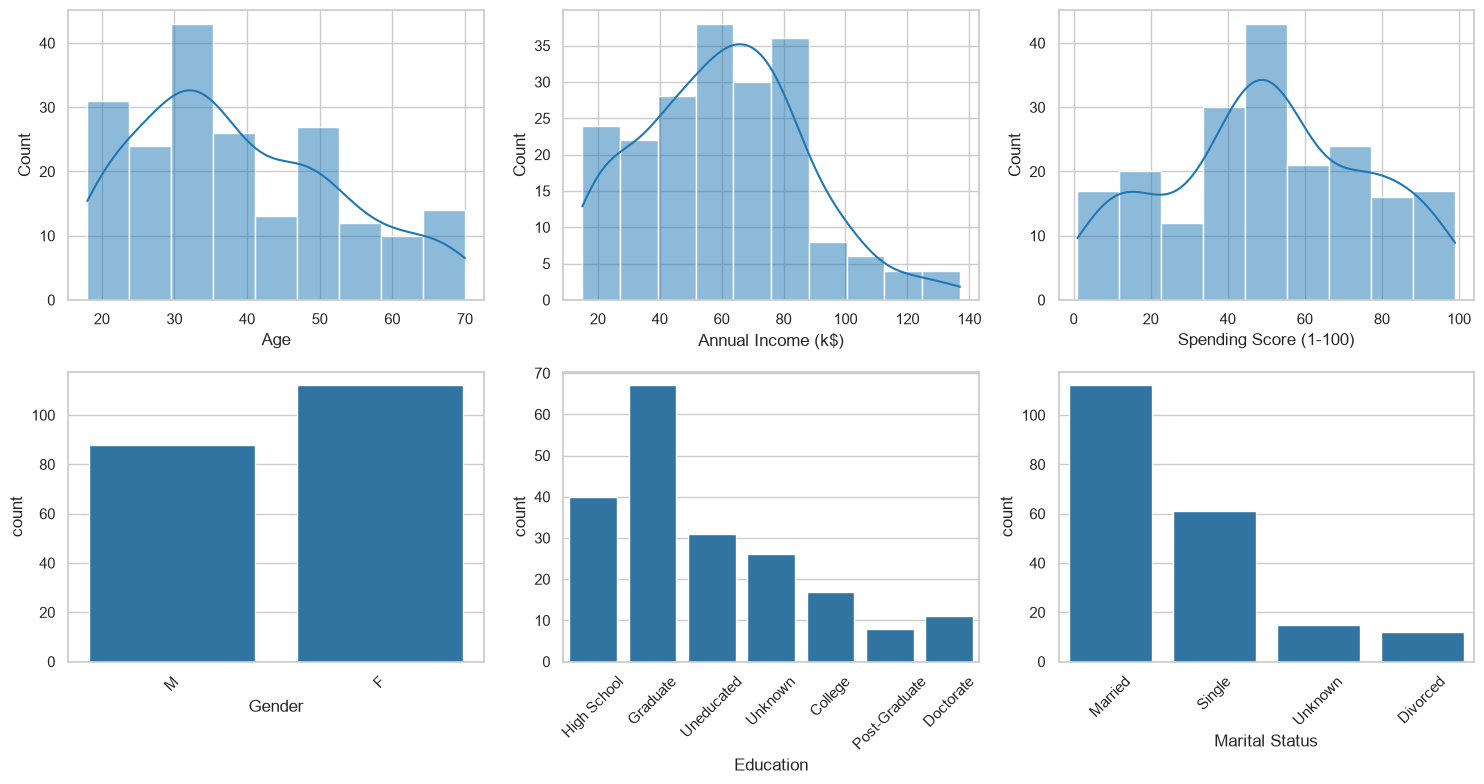

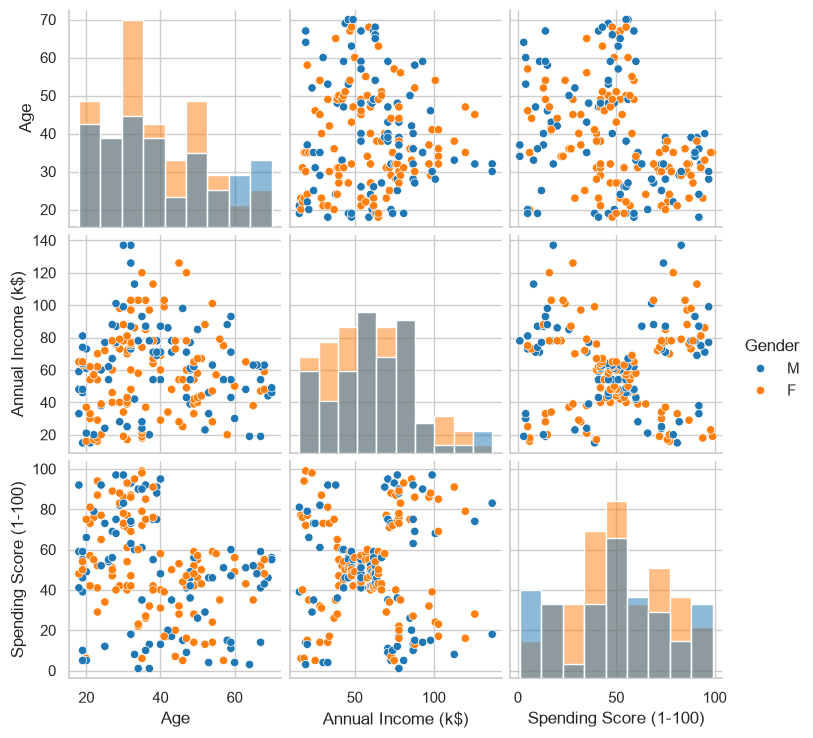

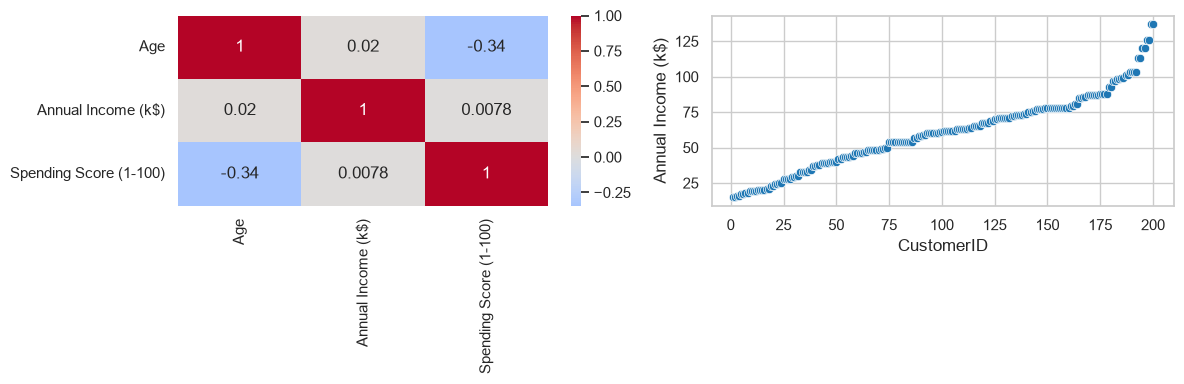

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for c, ax in zip(NUM, axes[0]):
    sns.histplot(df[c], kde=True, ax=ax)
for c, ax in zip(CAT, axes[1]):
    sns.countplot(data=df, x=c, ax=ax)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
sns.pairplot(df[NUM + ['Gender']], hue='Gender', diag_kind='hist'); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(df[NUM].corr(method='spearman'), annot=True, cmap='coolwarm', center=0, ax=axes[0])
sns.scatterplot(data=df, x=ID, y='Annual Income (k$)', ax=axes[1])
plt.tight_layout(); plt.show()

**EDA interpretation.** The income/spending plane should be inspected before choosing a model. Near-zero correlation does not imply absence of clusters. The ID is ordered with income and would introduce artificial distance. `Unknown` education/marital values are not genuine known demographic categories; later sensitivity checks remove these two columns. With only 200 observations, complicated partitions and tiny clusters need particularly strong scrutiny.

## 2. Feature spaces and evaluation protocol
We search Standard, Robust and MinMax scaling for numeric scopes. For mixed data we use standardized numeric features and one-hot categorical blocks, with weights 0.25, 0.5 and 1. A mismatch in one categorical variable contributes `weight²` to squared Euclidean distance because each one-hot block is divided by √2. A separate **Gower-style** distance experiment treats each original variable equally and checks a genuinely mixed-data geometry.

To avoid picking a scaler simply because it changes the score, every candidate in a scope is also scored in that scope's **fixed reference geometry**: standardized numerics and categorical weight 0.5. Silhouettes across scopes remain different objectives and are never pooled for selection. PCA plots are visualization only; we do not optimize a t-SNE/UMAP plot.

Eligibility: 2–10 clusters, at least 90% coverage and at least 5 customers per cluster. Density algorithms get silhouette only on assigned points, plus a coverage penalty: `reference silhouette − (1 − coverage)`. Noise is not an extra customer segment. We report own-space silhouette, reference silhouette, DB and CH, cluster sizes, coverage, warnings and failures. Top two eligible configurations per model family and scope undergo 20 independent 80% subsample refits, **refitting preprocessing each time**. The final score subtracts `0.15 × (1 − median ARI)`; this is an explicit heuristic, not a statistical theorem. Sensitivity to that weight is reported.

In [4]:
SCOPES = {'behavior': NUM[1:], 'behavior_age': NUM, 'all_features': NUM + CAT}
def make_preprocessor(scope, scaling='standard', cat_weight=.5):
    nums = [c for c in SCOPES[scope] if c in NUM]
    cats = [c for c in SCOPES[scope] if c in CAT]
    scaler = {'standard': StandardScaler, 'robust': RobustScaler, 'minmax': MinMaxScaler}[scaling]()
    blocks = [('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler)]), nums)]
    weights = {'numeric': 1.0}
    if cats:
        blocks.append(('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats))
        weights['categorical'] = cat_weight / np.sqrt(2)
    return ColumnTransformer(blocks, transformer_weights=weights, verbose_feature_names_out=False)

reps, reference, reference_distances = {}, {}, {}
for scope in SCOPES:
    reference[scope] = make_preprocessor(scope).fit_transform(df)
    reference_distances[scope] = pairwise_distances(reference[scope])
    combinations = [('standard', w) for w in [.25,.5,1.0]] if scope == 'all_features' else [(s,.5) for s in ['standard','robust','minmax']]
    for scaling, weight in combinations:
        name = f'{scope}/{scaling}/cat={weight}'
        prep = make_preprocessor(scope, scaling, weight)
        reps[name] = dict(scope=scope, scaling=scaling, cat_weight=weight, prep=prep, X=prep.fit_transform(df))

def make_model(family, params, seed=SEED):
    p = dict(params)
    if family == 'KMeans': return KMeans(**p, n_init=30, random_state=seed)
    if family == 'GMM': return GaussianMixture(**p, n_init=5, max_iter=500, reg_covar=1e-5, random_state=seed)
    if family == 'Agglomerative': return AgglomerativeClustering(**p)
    if family == 'DBSCAN': return DBSCAN(**p)
    if family == 'HDBSCAN': return HDBSCAN(**p, copy=True)
    if family == 'Spectral': return SpectralClustering(**p, assign_labels='cluster_qr', random_state=seed)
    if family == 'Birch': return Birch(**p)
    if family == 'OPTICS': return OPTICS(**p)
    raise ValueError(family)

def measure(labels, X, scope, precomputed=False):
    mask = labels >= 0
    sizes = pd.Series(labels[mask]).value_counts()
    k, coverage = len(sizes), float(mask.mean())
    result = dict(k=k, coverage=coverage, min_size=int(sizes.min()) if k else 0,
                  max_size=int(sizes.max()) if k else 0, silhouette=np.nan, ref_silhouette=np.nan,
                  db=np.nan, ch=np.nan, penalized=-np.inf, eligible=False)
    if 2 <= k < mask.sum():
        own = X[np.ix_(mask,mask)] if precomputed else X[mask]
        result['silhouette'] = silhouette_score(own, labels[mask], metric='precomputed' if precomputed else 'euclidean')
        result['ref_silhouette'] = silhouette_score(reference_distances[scope][np.ix_(mask,mask)], labels[mask], metric='precomputed')
        result['db'] = davies_bouldin_score(reference[scope][mask], labels[mask])
        result['ch'] = calinski_harabasz_score(reference[scope][mask], labels[mask])
        result['penalized'] = result['ref_silhouette'] - (1-coverage)
        result['eligible'] = bool(k <= 10 and coverage >= .9 and sizes.min() >= 5)
    return result

def configurations(X):
    for k in range(2, 11):
        yield 'KMeans', dict(n_clusters=k)
        for cov in ['full','tied','diag','spherical']:
            yield 'GMM', dict(n_components=k, covariance_type=cov)
        for link in ['ward','complete','average']:
            yield 'Agglomerative', dict(n_clusters=k, linkage=link)
        for nn in [10,20]:
            yield 'Spectral', dict(n_clusters=k, affinity='nearest_neighbors', n_neighbors=nn)
        for threshold in [.2,.5]:
            yield 'Birch', dict(n_clusters=k, threshold=threshold)
    distances = pairwise_distances(X)
    for minimum in [4,7,10]:
        kth = np.sort(distances, axis=1)[:,minimum-1]
        for eps in np.unique(np.quantile(kth, [.4,.6,.8,.9,.95])):
            yield 'DBSCAN', dict(eps=float(eps), min_samples=minimum)
    for size in [5,10,15,20]:
        for minimum in [3,5,10]:
            for selection in ['eom','leaf']:
                yield 'HDBSCAN', dict(min_cluster_size=size, min_samples=minimum, cluster_selection_method=selection)
    for minimum in [5,10]:
        for xi in [.03,.05,.1]:
            yield 'OPTICS', dict(min_samples=minimum, xi=xi, min_cluster_size=.05)

records, labels_by_id, specs = [], {}, {}
started = time.time()
for rep_name, rep in reps.items():
    X, scope = rep['X'], rep['scope']
    for family, params in configurations(X):
        cid = len(records)
        row = dict(id=cid, scope=scope, representation=rep_name, family=family, params=json.dumps(params, sort_keys=True),
                   status='ok', warning='', bic=np.nan, aic=np.nan)
        specs[cid] = (rep_name, family, params)
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                model = make_model(family, params)
                labels = model.fit_predict(X)
            row['warning'] = ' | '.join(sorted(set(str(w.message) for w in caught)))
            row.update(measure(labels, X, scope))
            if family == 'GMM':
                row.update(bic=model.bic(X), aic=model.aic(X))
                if not model.converged_: row.update(status='not_converged', eligible=False)
            labels_by_id[cid] = labels
        except Exception as exc:
            row.update(status=f'{type(exc).__name__}: {exc}', eligible=False)
        records.append(row)
    print(rep_name, '| cumulative fits:', len(records), '| seconds:', round(time.time()-started,1), flush=True)
results = pd.DataFrame(records).set_index('id', drop=False)
results.to_csv(OUT / 'search_results.csv', index=False)
display(results.groupby(['scope','family']).agg(tried=('id','size'), eligible=('eligible','sum')))
display(results.loc[results.status.ne('ok'), ['family','status']].head(20))
print('Fits with warnings:', results.warning.ne('').sum())

behavior/standard/cat=0.5 | cumulative fits: 153 | seconds: 2.3


behavior/robust/cat=0.5 | cumulative fits: 306 | seconds: 4.6


behavior/minmax/cat=0.5 | cumulative fits: 459 | seconds: 7.2


behavior_age/standard/cat=0.5 | cumulative fits: 612 | seconds: 9.7


behavior_age/robust/cat=0.5 | cumulative fits: 765 | seconds: 12.6


...

all_features/standard/cat=0.5 | cumulative fits: 1224 | seconds: 21.2


all_features/standard/cat=1.0 | cumulative fits: 1377 | seconds: 24.2


tried  eligible
scope        family                        
all_features Agglomerative     81        54
             Birch             54        41
             DBSCAN            45         0
             GMM              108        95
             HDBSCAN           72         4
             KMeans            27        27
             OPTICS            18         0
             Spectral          54        54
behavior     Agglomerative     81        45
             Birch             54        24
             DBSCAN            45        11
             GMM              108        93
             HDBSCAN           72         6
             KMeans            27        27
             OPTICS            18         0
             Spectral          54        54
behavior_age Agglomerative     81        58
             Birch             54        25
             DBSCAN            45         0
             GMM              108        89
             HDBSCAN           72         3
             KMeans            27        27
             OPTICS            18         0
             Spectral          54        54

,family,status
id,,


Fits with warnings: 55


## 3. Mixed-data cross-check: Gower-style distance
Numerics contribute range-normalized absolute difference; each nominal variable contributes 0/1 mismatch. All six original features have equal weight. `Unknown` is treated as its own category here, not pairwise omitted; this is why we call the distance Gower-style. Average/complete linkage and density methods can use this matrix directly. Own-space scores for this experiment must not be compared with Euclidean silhouettes; the fixed reference score remains the common ranking geometry.

In [5]:
def gower_distance(data):
    numeric = data[NUM].fillna(data[NUM].median()).to_numpy(float)
    ranges = np.ptp(numeric, axis=0)
    ranges[ranges == 0] = 1
    d = np.abs(numeric[:,None,:] - numeric[None,:,:]) / ranges
    categorical = data[CAT].to_numpy()
    mismatch = (categorical[:,None,:] != categorical[None,:,:]).astype(float)
    return (d.sum(axis=2) + mismatch.sum(axis=2)) / (len(NUM)+len(CAT))

G = gower_distance(df)
gower_configs = [('Agglomerative',dict(n_clusters=k, linkage=l, metric='precomputed')) for k in range(2,11) for l in ['average','complete']]
gower_configs += [('HDBSCAN',dict(min_cluster_size=s, min_samples=m, metric='precomputed')) for s in [5,10,15,20] for m in [3,5,10]]
for family, params in gower_configs:
    cid = len(records)
    model = make_model(family, params)
    labels = model.fit_predict(G)
    row = dict(id=cid, scope='all_features', representation='gower', family=family,
               params=json.dumps(params, sort_keys=True), status='ok', warning='', bic=np.nan, aic=np.nan)
    row.update(measure(labels, G, 'all_features', precomputed=True))
    records.append(row); labels_by_id[cid] = labels; specs[cid] = ('gower',family,params)
results = pd.DataFrame(records).set_index('id', drop=False)
results.to_csv(OUT / 'search_results.csv', index=False)
display(results[results.eligible].sort_values('penalized', ascending=False).groupby('scope', sort=False).head(8)[['scope','family','representation','params','k','silhouette','ref_silhouette','coverage','min_size','penalized']])
display(results[results.representation.eq('gower')].sort_values('penalized', ascending=False).head(5))

,scope,family,representation,params,k,silhouette,ref_silhouette,coverage,min_size,penalized
id,,,,,,,,,,
36,behavior,KMeans,behavior/standard/cat=0.5,"{""n_clusters"": 5}",5,0.554657,0.554657,1.0,22,0.554657
342,behavior,KMeans,behavior/minmax/cat=0.5,"{""n_clusters"": 5}",5,0.559485,0.554657,1.0,22,0.554657
189,behavior,KMeans,behavior/robust/cat=0.5,"{""n_clusters"": 5}",5,0.551652,0.554657,1.0,22,0.554657
46,behavior,Birch,behavior/standard/cat=0.5,"{""n_clusters"": 5, ""threshold"": 0.2}",5,0.553809,0.553809,1.0,21,0.553809
41,behavior,Agglomerative,behavior/standard/cat=0.5,"{""linkage"": ""ward"", ""n_clusters"": 5}",5,0.553809,0.553809,1.0,21,0.553809
195,behavior,Agglomerative,behavior/robust/cat=0.5,"{""linkage"": ""complete"", ""n_clusters"": 5}",5,0.550407,0.553809,1.0,21,0.553809
194,behavior,Agglomerative,behavior/robust/cat=0.5,"{""linkage"": ""ward"", ""n_clusters"": 5}",5,0.550407,0.553809,1.0,21,0.553809
40,behavior,GMM,behavior/standard/cat=0.5,"{""covariance_type"": ""spherical"", ""n_components...",5,0.553804,0.553804,1.0,21,0.553804
813,behavior_age,KMeans,behavior_age/minmax/cat=0.5,"{""n_clusters"": 6}",6,0.423486,0.429349,1.0,19,0.429349


,id,scope,representation,family,params,status,warning,bic,aic,k,coverage,min_size,max_size,silhouette,ref_silhouette,db,ch,penalized,eligible
id,,,,,,,,,,,,,,,,,,,
1377,1377,all_features,gower,Agglomerative,"{""linkage"": ""average"", ""metric"": ""precomputed""...",ok,,NaN,NaN,2,1.0,79,121,0.277520,0.041309,6.209893,4.541860,0.041309,True
1378,1378,all_features,gower,Agglomerative,"{""linkage"": ""complete"", ""metric"": ""precomputed...",ok,,NaN,NaN,2,1.0,84,116,0.293657,0.033412,6.536090,4.115266,0.033412,True
1380,1380,all_features,gower,Agglomerative,"{""linkage"": ""complete"", ""metric"": ""precomputed...",ok,,NaN,NaN,3,1.0,9,107,0.268404,-0.039195,5.636143,2.757370,-0.039195,True
1382,1382,all_features,gower,Agglomerative,"{""linkage"": ""complete"", ""metric"": ""precomputed...",ok,,NaN,NaN,4,1.0,9,107,0.247351,-0.056384,5.685630,2.535376,-0.056384,True
1384,1384,all_features,gower,Agglomerative,"{""linkage"": ""complete"", ""metric"": ""precomputed...",ok,,NaN,NaN,5,1.0,9,58,0.196857,-0.064523,6.768386,2.181119,-0.064523,True


## 4. Resampling stability and selection
ARI compares each subsample refit with the full-data solution restricted to the same customers. This measures perturbation stability, not predictive accuracy. Noise agreement is reported separately because treating all noise as one cluster can inflate ARI. We additionally report ARI on points assigned by both fits, coverage and the fraction of subsamples recovering the original cluster count. Empirical 10th/90th percentiles are perturbation ranges, not confidence intervals.

In [6]:
shortlist = (results[results.eligible & results.status.eq('ok')].sort_values('penalized', ascending=False)
             .groupby(['scope','family'], sort=False).head(2))
stability_rows = []
for cid in shortlist.id:
    rep_name, family, params = specs[cid]
    original = labels_by_id[cid]
    local_rng = np.random.default_rng(SEED+100)
    for repeat in range(20):
        idx = np.sort(local_rng.choice(len(df), int(.8*len(df)), replace=False))
        try:
            if rep_name == 'gower': Xsub = gower_distance(df.iloc[idx])
            else: Xsub = clone(reps[rep_name]['prep']).fit_transform(df.iloc[idx])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                lab = make_model(family, params, SEED+repeat).fit_predict(Xsub)
            both = (lab >= 0) & (original[idx] >= 0)
            assigned_ari = adjusted_rand_score(original[idx][both],lab[both]) if both.sum()>1 and len(np.unique(lab[both]))>1 and len(np.unique(original[idx][both]))>1 else np.nan
            stability_rows.append(dict(id=cid, repeat=repeat, ari=adjusted_rand_score(original[idx],lab),
                assigned_ari=assigned_ari, coverage=float((lab>=0).mean()),
                same_k=len(set(lab)-{-1}) == results.loc[cid,'k'],
                noise_agreement=float(((lab<0)==(original[idx]<0)).mean()), error=''))
        except Exception as exc:
            stability_rows.append(dict(id=cid, repeat=repeat, ari=np.nan, assigned_ari=np.nan,coverage=np.nan,same_k=False,noise_agreement=np.nan,error=str(exc)))
stability = pd.DataFrame(stability_rows)
summary = stability.groupby('id').agg(ari_median=('ari','median'), ari_p10=('ari',lambda x:x.quantile(.1)),
    ari_p90=('ari',lambda x:x.quantile(.9)), assigned_ari=('assigned_ari','median'),
    subsample_coverage=('coverage','median'), same_k_rate=('same_k','mean'), valid_repeats=('ari','count'))
ranked = shortlist.join(summary)
ranked['final_score'] = ranked.penalized - .15*(1-ranked.ari_median)
ranked = ranked[ranked.valid_repeats.eq(20)].sort_values(['scope','final_score'], ascending=[True,False])
winners = ranked.groupby('scope', sort=False).head(1)
display(winners[['scope','family','representation','params','k','ref_silhouette','coverage','ari_median','ari_p10','same_k_rate','final_score']])
display(ranked.groupby('scope', sort=False).head(6)[['scope','family','k','ref_silhouette','coverage','ari_median','final_score']])
stability.to_csv(OUT/'stability_trials.csv', index=False)
ranked.to_csv(OUT/'validated_leaderboard.csv', index=False)
sensitivity = []
for weight in [0,.05,.15,.30]:
    temp = ranked.assign(score=ranked.penalized-weight*(1-ranked.ari_median))
    for scope, group in temp.groupby('scope'):
        best = group.loc[group.score.idxmax()]
        sensitivity.append(dict(stability_weight=weight,scope=scope,id=int(best.id),family=best.family,k=int(best.k)))
display(pd.DataFrame(sensitivity))

,scope,family,representation,params,k,ref_silhouette,coverage,ari_median,ari_p10,same_k_rate,final_score
id,,,,,,,,,,,
954,all_features,KMeans,all_features/standard/cat=0.25,"{""n_clusters"": 5}",5,0.350322,1.0,0.984233,0.631104,1.0,0.347956
36,behavior,KMeans,behavior/standard/cat=0.5,"{""n_clusters"": 5}",5,0.554657,1.0,0.991677,0.929956,1.0,0.553409
660,behavior_age,KMeans,behavior_age/robust/cat=0.5,"{""n_clusters"": 6}",6,0.429211,1.0,0.980047,0.946851,1.0,0.426218


,scope,family,k,ref_silhouette,coverage,ari_median,final_score
id,,,,,,,
954,all_features,KMeans,5,0.350322,1.0,0.984233,0.347956
1107,all_features,KMeans,5,0.350322,1.0,0.983884,0.347904
1123,all_features,GMM,6,0.348597,1.0,0.989411,0.347009
970,all_features,GMM,6,0.348597,1.0,0.982212,0.345929
1257,all_features,Spectral,4,0.342795,1.0,0.938616,0.333587
1271,all_features,Birch,5,0.346878,1.0,0.909240,0.333264
36,behavior,KMeans,5,0.554657,1.0,0.991677,0.553409
342,behavior,KMeans,5,0.554657,1.0,0.981296,0.551852
40,behavior,GMM,5,0.553804,1.0,0.983157,0.551277


,stability_weight,scope,id,family,k
0,0.00,all_features,954,KMeans,5
1,0.00,behavior,36,KMeans,5
2,0.00,behavior_age,813,KMeans,6
3,0.05,all_features,954,KMeans,5
4,0.05,behavior,36,KMeans,5
5,0.05,behavior_age,660,KMeans,6
6,0.15,all_features,954,KMeans,5
7,0.15,behavior,36,KMeans,5
8,0.15,behavior_age,660,KMeans,6
9,0.30,all_features,954,KMeans,5


## 5. Number of clusters and a search-aware null benchmark
KMeans elbow/silhouette and GMM BIC offer different perspectives. BIC is comparable only within the **same representation**, and may select a density model with a different segmentation than silhouette. Include one-component GMM and one-cluster KMeans rather than forcing evidence for multiple clusters. Gaussian likelihoods on one-hot categorical columns are only a heuristic: redundant dummy columns and regularization can distort BIC. Treat the all-feature GMM BIC as a diagnostic, not reliable evidence for a true number of demographic clusters.

The null benchmark independently permutes feature columns, preserves univariate distributions and destroys their dependence. We re-run the **KMeans k=2…10 search** on each of 99 null datasets. This corrects for that k search only, not the entire multi-family investigation. It is a diagnostic for joint structure beyond these marginals, not a universal test of whether clusters “exist”.

,scope,k,covariance,bic,converged
110,all_features,8,diag,-11923.807679,True
25,behavior,7,tied,1037.915976,True
58,behavior_age,5,diag,1521.736287,True


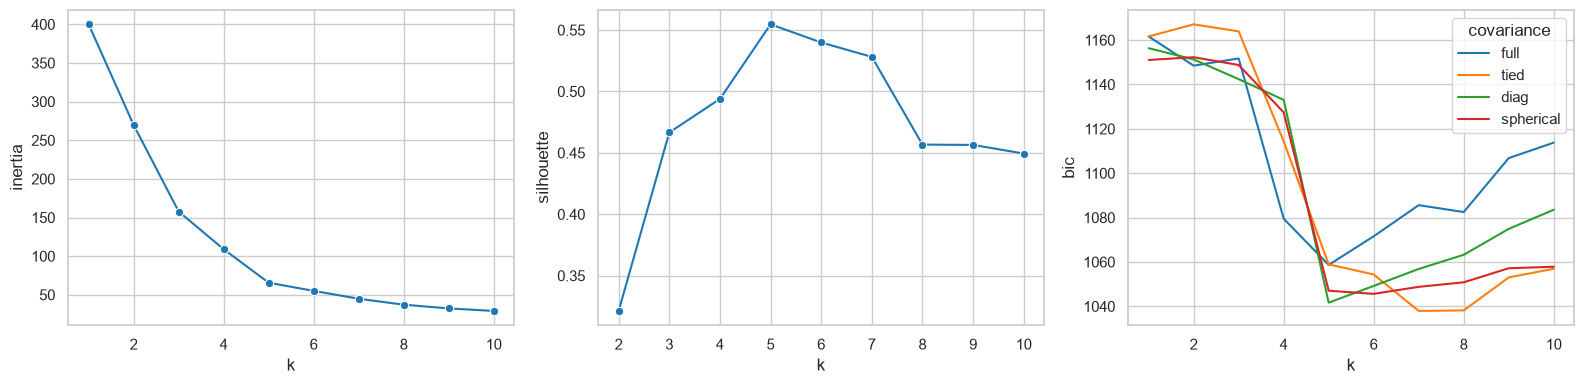

observed_best_kmeans_silhouette     0.554657
null_mean                           0.407136
null_p95                            0.426013
monte_carlo_p                       0.010000
permutations                       99.000000
dtype: float64

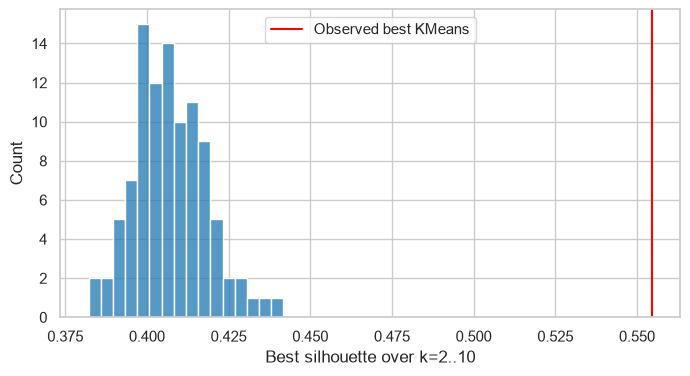

In [7]:
primary_rep = next(n for n,r in reps.items() if r['scope']=='behavior' and r['scaling']=='standard')
Xb = reps[primary_rep]['X']
ks = list(range(1,11))
km_curve=[]
for k in ks:
    model=KMeans(n_clusters=k,n_init=30,random_state=SEED).fit(Xb)
    km_curve.append(dict(k=k,inertia=model.inertia_,silhouette=silhouette_score(Xb,model.labels_) if k>1 else np.nan))
curve=pd.DataFrame(km_curve)
bic_rows=[]
for scope in SCOPES:
    rep_name=next(n for n,r in reps.items() if r['scope']==scope and r['scaling']=='standard' and r['cat_weight']==.5)
    X=reps[rep_name]['X']
    for k in ks:
        for cov in ['full','tied','diag','spherical']:
            model=make_model('GMM',dict(n_components=k,covariance_type=cov)).fit(X)
            bic_rows.append(dict(scope=scope,k=k,covariance=cov,bic=model.bic(X),converged=model.converged_))
bic_table=pd.DataFrame(bic_rows)
display(bic_table[bic_table.converged].sort_values('bic').groupby('scope').head(1))
fig,axes=plt.subplots(1,3,figsize=(16,4))
sns.lineplot(data=curve,x='k',y='inertia',marker='o',ax=axes[0])
sns.lineplot(data=curve,x='k',y='silhouette',marker='o',ax=axes[1])
sns.lineplot(data=bic_table[bic_table.scope.eq('behavior')],x='k',y='bic',hue='covariance',ax=axes[2])
plt.tight_layout();plt.show()
null_rng=np.random.default_rng(SEED+200)
null_scores=[]
for repeat in range(99):
    permuted=np.column_stack([null_rng.permutation(Xb[:,j]) for j in range(Xb.shape[1])])
    null_scores.append(max(silhouette_score(permuted,KMeans(n_clusters=k,n_init=30,random_state=SEED).fit_predict(permuted)) for k in range(2,11)))
observed=float(curve.silhouette.max())
null_p=(1+np.sum(np.asarray(null_scores)>=observed))/(1+len(null_scores))
null_result=dict(observed_best_kmeans_silhouette=observed, null_mean=float(np.mean(null_scores)),
                 null_p95=float(np.quantile(null_scores,.95)), monte_carlo_p=float(null_p), permutations=99)
display(pd.Series(null_result))
plt.figure(figsize=(8,4));sns.histplot(null_scores,bins=16)
plt.axvline(observed,color='red',label='Observed best KMeans');plt.legend();plt.xlabel('Best silhouette over k=2..10');plt.show()
bic_table.to_csv(OUT/'gmm_bic.csv',index=False)
pd.DataFrame({'null_best_silhouette':null_scores}).to_csv(OUT/'null_benchmark.csv',index=False)

## 6. Independent holdout diagnostic for assignable models
For KMeans/GMM only: reserve 25% of rows using a fixed random split, re-run k/covariance selection on training data alone, fit preprocessing on training data alone, and predict the untouched holdout. Holdout silhouette describes separation of those assignments, not classification accuracy. This is a supplementary fixed-split diagnostic, not the basis for the previously selected full-data winner. A single 50-customer holdout is noisy. Refitting the final model on all data is intentional.

In [8]:
train_idx,test_idx=train_test_split(np.arange(len(df)),test_size=.25,random_state=SEED+300)
holdout_rows=[]
for scope in SCOPES:
    prep=make_preprocessor(scope)
    xtrain=prep.fit_transform(df.iloc[train_idx]);xtest=prep.transform(df.iloc[test_idx])
    for family in ['KMeans','GMM']:
        candidates=[]
        for k in range(2,11):
            for cov in (['full','tied','diag','spherical'] if family=='GMM' else [None]):
                params=dict(n_clusters=k) if family=='KMeans' else dict(n_components=k,covariance_type=cov)
                model=make_model(family,params).fit(xtrain)
                labels=model.predict(xtrain)
                sizes=pd.Series(labels).value_counts()
                if len(sizes)>1 and sizes.min()>=5 and getattr(model,'converged_',True):
                    candidates.append((silhouette_score(xtrain,labels),params,model))
        train_score,params,model=max(candidates,key=lambda z:z[0])
        test_labels=model.predict(xtest)
        test_score=silhouette_score(xtest,test_labels) if 1<len(np.unique(test_labels))<len(test_labels) else np.nan
        holdout_rows.append(dict(scope=scope,family=family,params=json.dumps(params),train_silhouette=train_score,
                                  holdout_silhouette=test_score,holdout_clusters=len(np.unique(test_labels)),holdout_min_size=int(pd.Series(test_labels).value_counts().min())))
holdout=pd.DataFrame(holdout_rows);display(holdout)
holdout.to_csv(OUT/'holdout_diagnostic.csv',index=False)

,scope,family,params,train_silhouette,holdout_silhouette,holdout_clusters,holdout_min_size
0,behavior,KMeans,"{""n_clusters"": 6}",0.567723,0.473524,6,1
1,behavior,GMM,"{""n_components"": 6, ""covariance_type"": ""tied""}",0.571052,0.483786,6,1
2,behavior_age,KMeans,"{""n_clusters"": 9}",0.424431,0.293914,9,1
3,behavior_age,GMM,"{""n_components"": 9, ""covariance_type"": ""tied""}",0.424774,0.371867,8,2
4,all_features,KMeans,"{""n_clusters"": 5}",0.356122,0.319043,5,4
5,all_features,GMM,"{""n_components"": 4, ""covariance_type"": ""spheri...",0.355659,0.304441,4,10


## 7. Final segments, ambiguity and robustness
Choose the behavior winner for the stated customer-spending use case. Cluster numbers are arbitrary, not rankings. Per-customer silhouette highlights boundary cases; it is not a calibrated probability. If the winner is a GMM, posterior membership is also provided, conditional on that mixture model. All-feature assignments are exported separately and should be considered if demographics are part of the objective.

,n,age_mean,income_mean,income_median,spending_mean,spending_median,silhouette_mean
cluster_behavior,,,,,,,
0,81,42.716,55.296,54.0,49.519,50.0,0.598
1,39,32.692,86.538,79.0,82.128,83.0,0.511
2,22,25.273,25.727,24.5,79.364,77.0,0.598
3,35,41.114,88.200,85.0,17.114,16.0,0.505
4,23,45.217,26.304,25.0,20.913,17.0,0.511


Gender,F,M
cluster_behavior,,
0,0.593,0.407
1,0.538,0.462
2,0.591,0.409
3,0.457,0.543
4,0.609,0.391


Education,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated,Unknown
cluster_behavior,,,,,,,
0,0.062,0.074,0.383,0.198,0.037,0.099,0.148
1,0.103,0.051,0.333,0.154,0.051,0.205,0.103
2,0.091,0.045,0.318,0.182,0.000,0.091,0.273
3,0.114,0.029,0.229,0.286,0.057,0.257,0.029
4,0.087,0.043,0.348,0.174,0.043,0.174,0.130


Marital Status,Divorced,Married,Single,Unknown
cluster_behavior,,,,
0,0.062,0.543,0.333,0.062
1,0.103,0.590,0.256,0.051
2,0.000,0.545,0.273,0.182
3,0.057,0.600,0.314,0.029
4,0.043,0.522,0.304,0.130


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),cluster_all_features,cluster_behavior,cluster_behavior_age,behavior_silhouette,boundary_flag
146,147,M,48,Graduate,Single,77,36,3,3,4,-0.028574,True
42,43,M,48,College,Single,39,36,1,4,2,-0.012125,True
124,125,F,23,College,Single,70,29,3,3,1,0.007644,True
45,46,F,24,Uneducated,Single,39,65,0,2,5,0.049646,True
40,41,F,65,Graduate,Single,38,35,4,4,0,0.090763,True
160,161,F,56,High School,Married,79,35,4,3,0,0.096802,True
132,133,F,25,Graduate,Married,72,34,3,0,1,0.115977,False
43,44,F,31,High School,Married,39,61,0,0,5,0.121141,False
142,143,F,28,Graduate,Married,76,40,3,0,1,0.198449,False
126,127,M,43,Graduate,Single,71,35,3,0,4,0.200074,False


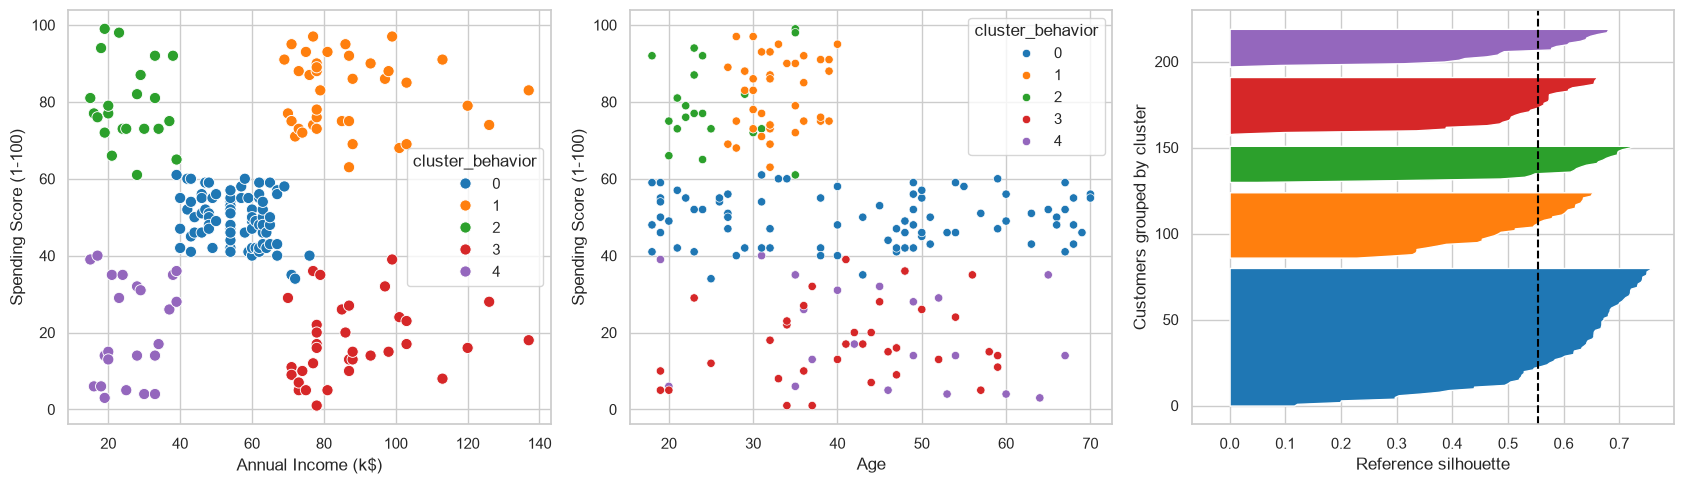

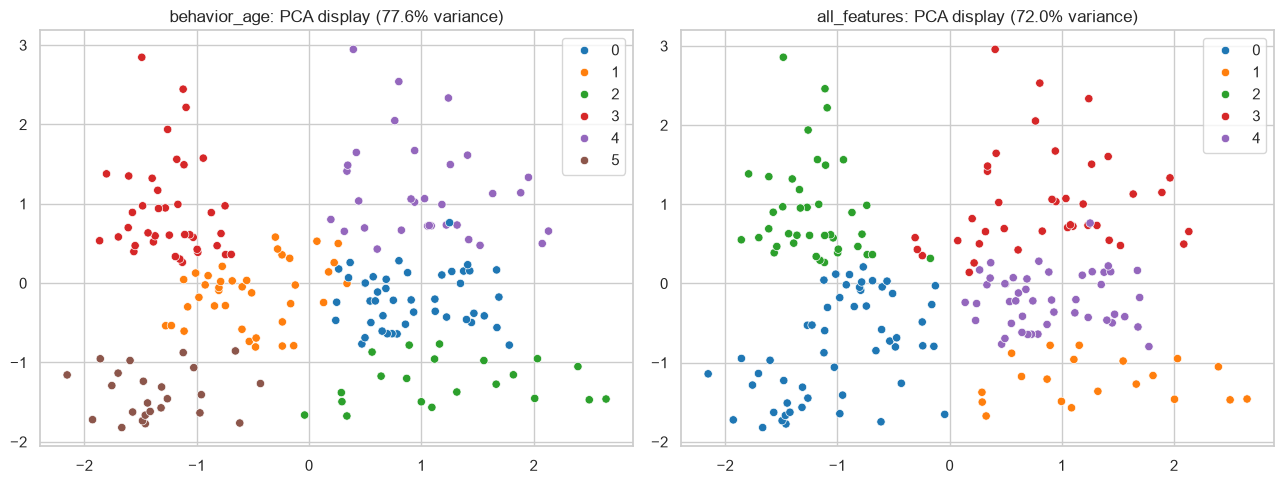

,behavior,behavior_age,all_features
behavior,1.000000,0.682131,0.584468
behavior_age,0.682131,1.000000,0.768960
all_features,0.584468,0.768960,1.000000


In [9]:
winner_ids={row.scope:int(row.id) for _,row in winners.iterrows()}
best_id=winner_ids['behavior']
best=results.loc[best_id]
rep_name,family,params=specs[best_id]
prep=clone(reps[rep_name]['prep'])
Xfinal=prep.fit_transform(df)
final_model=make_model(family,params)
final_labels=final_model.fit_predict(Xfinal)
assert adjusted_rand_score(final_labels,labels_by_id[best_id])>.999999
assigned=final_labels>=0
point_silhouette=np.full(len(df),np.nan)
point_silhouette[assigned]=silhouette_samples(reference['behavior'][assigned],final_labels[assigned])
customers=df.copy()
for scope,cid in winner_ids.items(): customers[f'cluster_{scope}']=labels_by_id[cid]
customers['behavior_silhouette']=point_silhouette
customers['boundary_flag']=(point_silhouette<.1)|~assigned
if family=='GMM': customers['max_posterior']=final_model.predict_proba(Xfinal).max(axis=1)
profile=customers.groupby('cluster_behavior').agg(n=(ID,'size'),age_mean=('Age','mean'),income_mean=('Annual Income (k$)','mean'),
    income_median=('Annual Income (k$)','median'),spending_mean=('Spending Score (1-100)','mean'),spending_median=('Spending Score (1-100)','median'),silhouette_mean=('behavior_silhouette','mean'))
display(profile.round(3))
for c in CAT:
    display(pd.crosstab(customers.cluster_behavior,customers[c],normalize='index').round(3))
display(customers.sort_values('behavior_silhouette').head(12))
fig,axes=plt.subplots(1,3,figsize=(17,5))
sns.scatterplot(data=customers,x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster_behavior',palette='tab10',s=65,ax=axes[0])
sns.scatterplot(data=customers,x='Age',y='Spending Score (1-100)',hue='cluster_behavior',palette='tab10',ax=axes[1])
y=0
for cluster in sorted(set(final_labels)-{-1}):
    values=np.sort(point_silhouette[final_labels==cluster]);axes[2].fill_betweenx(np.arange(y,y+len(values)),0,values,label=str(cluster));y+=len(values)+5
axes[2].axvline(np.nanmean(point_silhouette),color='black',linestyle='--');axes[2].set(xlabel='Reference silhouette',ylabel='Customers grouped by cluster')
plt.tight_layout();plt.savefig(OUT/'final_clusters.png',dpi=160,bbox_inches='tight');plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,5))
for scope,ax in zip(['behavior_age','all_features'],axes):
    pca=PCA(n_components=2).fit(reference[scope]);xy=pca.transform(reference[scope])
    sns.scatterplot(x=xy[:,0],y=xy[:,1],hue=labels_by_id[winner_ids[scope]],palette='tab10',ax=ax)
    ax.set_title(f'{scope}: PCA display ({pca.explained_variance_ratio_.sum():.1%} variance)')
plt.tight_layout();plt.show()
agreement=pd.DataFrame(index=SCOPES,columns=SCOPES,dtype=float)
for a in SCOPES:
    for b in SCOPES: agreement.loc[a,b]=adjusted_rand_score(labels_by_id[winner_ids[a]],labels_by_id[winner_ids[b]])
display(agreement)

In [10]:
# Seed sensitivity, realistic measurement jitter, and leave-one-out influence.
robustness_rows=[]
for repeat in range(30):
    lab=make_model(family,params,SEED+1000+repeat).fit_predict(Xfinal)
    robustness_rows.append(dict(check='random_seed',repeat=repeat,ari=adjusted_rand_score(final_labels,lab)))
    jittered=df.copy()
    local=np.random.default_rng(SEED+2000+repeat)
    jittered['Annual Income (k$)']=np.maximum(0,df['Annual Income (k$)']+local.normal(0,1,len(df)))
    jittered['Spending Score (1-100)']=np.clip(df['Spending Score (1-100)']+local.normal(0,1,len(df)),1,100)
    x=clone(prep).fit_transform(jittered)
    lab=make_model(family,params,SEED+repeat).fit_predict(x)
    robustness_rows.append(dict(check='income_and_spend_jitter_sd_1',repeat=repeat,ari=adjusted_rand_score(final_labels,lab)))
for i in range(len(df)):
    mask=np.arange(len(df))!=i
    x=clone(prep).fit_transform(df.loc[mask])
    lab=make_model(family,params).fit_predict(x)
    robustness_rows.append(dict(check='leave_one_out',repeat=i,ari=adjusted_rand_score(final_labels[mask],lab)))
robustness=pd.DataFrame(robustness_rows)
display(robustness.groupby('check').ari.agg(['min','median','mean','max']))
robustness.to_csv(OUT/'robustness.csv',index=False)

# Remove both fields containing Unknown tokens; quantify demographic dependence.
full_id=winner_ids['all_features'];full_rep,full_family,full_params=specs[full_id]
if full_rep != 'gower':
    base=reps[full_rep]
    reduced=ColumnTransformer([
        ('numeric',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),NUM),
        ('gender',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['Gender'])],
        transformer_weights={'numeric':1,'gender':base['cat_weight']/np.sqrt(2)})
    xr=reduced.fit_transform(df)
else:
    xn=MinMaxScaler().fit_transform(df[NUM]);g=df.Gender.to_numpy()
    xr=(np.abs(xn[:,None,:]-xn[None,:,:]).sum(axis=2)+(g[:,None]!=g[None,:]))/4
reduced_labels=make_model(full_family,full_params).fit_predict(xr)
demographic_sensitivity=adjusted_rand_score(labels_by_id[full_id],reduced_labels)
print('All-feature ARI after removing Education and Marital Status:',round(demographic_sensitivity,4))

,min,median,mean,max
check,,,,
income_and_spend_jitter_sd_1,0.930171,0.984717,0.979040,1.0
leave_one_out,0.984637,1.000000,0.999014,1.0
random_seed,1.000000,1.000000,1.000000,1.0


All-feature ARI after removing Education and Marital Status: 1.0


## 8. Export and conclusions
The serialized bundle contains fitted preprocessing, model, feature contract and provenance. Models without `.predict` are transductive: their artifact supports inspection/refitting, not an invented assignment rule for new customers. A separately validated KMeans/GMM alternative can be used if out-of-sample assignment is required. Unsupervised scores do not establish marketing effectiveness, causality, or fairness. Demographic profiles are descriptive and are not evidence that demographic attributes should drive business decisions.

In [11]:
bundle=dict(preprocessor=prep,model=final_model,features=SCOPES['behavior'],scope='behavior',
            candidate_id=best_id,params=params,manifest=manifest,supports_predict=hasattr(final_model,'predict'))
joblib.dump(bundle,OUT/'best_behavior_model.joblib')
customers.to_csv(OUT/'customer_segments.csv',index=False)
profile.to_csv(OUT/'cluster_profiles.csv')
for scope,cid in winner_ids.items():
    rn,fam,par=specs[cid]
    pr=None if rn=='gower' else clone(reps[rn]['prep']).fit(df)
    xx=gower_distance(df) if pr is None else pr.transform(df)
    fitted=make_model(fam,par).fit(xx)
    joblib.dump(dict(preprocessor=pr,model=fitted,features=SCOPES[scope],representation=rn,params=par,
                     manifest=manifest,supports_predict=hasattr(fitted,'predict')),OUT/f'best_{scope}_bundle.joblib')
manifest.update(total_configurations=len(results),eligible_configurations=int(results.eligible.sum()),
                stability_refits=len(stability),winner_ids=winner_ids,null_benchmark=null_result,
                demographic_removal_ari=float(demographic_sensitivity))
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')
(OUT/'requirements-lock.txt').write_text('\n'.join(f'{p}=={v}' for p,v in versions.items())+'\n',encoding='utf-8')
lines=['# Measured clustering results','',f'Workbook SHA-256: `{manifest["sha256"]}`',
       f'Search: {len(results)} configurations; {len(stability)} resampling fits.',
       'Primary objective: customer spending behavior (income + spending score).','']
for _,row in winners.iterrows():
    lines.append(f'- **{row.scope}**: {row.family}, {row.params}; representation `{row.representation}`; '
                 f'k={int(row.k)}, reference silhouette={row.ref_silhouette:.4f}, coverage={row.coverage:.1%}, '
                 f'median stability ARI={row.ari_median:.4f}, 10th percentile={row.ari_p10:.4f}.')
lines += ['', '## Interpretation / تفسیر نتایج',
          '', 'KMeans settings in this run: init=k-means++, n_init=30, random_state=42, max_iter=300, algorithm=lloyd. Numeric imputation uses the median; final fitted scalers and categorical encoders are stored in each bundle.',
          '', 'برای رفتار خرید، درآمد و امتیاز خرید ورودی مدل‌اند. سن و مشخصات جمعیت‌شناختی در این مدل برای تفسیر خوشه‌ها استفاده می‌شوند. در مدل all_features تمام شش ویژگی غیرشناسه وارد مدل می‌شوند، با وزن دسته‌ای نمایش‌داده‌شده در جدول؛ این وزن یک انتخاب مدل‌سازی است، نه اهمیت علّی ویژگی‌ها.',
          '', f'حساسیت مدل همهٔ ویژگی‌ها به حذف تحصیلات و وضعیت تأهل: ARI={demographic_sensitivity:.4f}. مقدار یک یعنی حذف این دو ستون در همین تنظیمات، عضویت خوشه‌ها را تغییر نداده است؛ این نتیجه دربارهٔ کل دیتاست یا نبود هرگونه رابطه تعمیم داده نمی‌شود.',
          '', 'نتیجهٔ holdout را هم ببینید: تعداد خوشه‌ای که فقط از بخش آموزش انتخاب می‌شود ممکن است با مدل کل داده متفاوت باشد. خوشهٔ یک‌عضوی در holdout نشانهٔ نیاز به دادهٔ بیشتر است. امتیازهای داخلی کل داده، تضمین عملکرد آینده نیستند.',
          '', 'For demographic segmentation, inspect the lower tail of stability, not only its median. A low ARI at the 10th percentile means some modest changes in the customer sample alter the partition substantially.',
          '', 'Behavior cluster descriptions (descriptive, not causal):']
for cluster,row in profile.iterrows():
    lines.append(f'- Cluster {cluster}: n={int(row.n)}, mean income={row.income_mean:.1f} k$, mean spending score={row.spending_mean:.1f}/100, mean age={row.age_mean:.1f}.')
lines+=['',f'KMeans-only search-aware permutation diagnostic: observed={observed:.4f}, null 95th percentile={null_result["null_p95"]:.4f}, Monte Carlo p={null_p:.3f}.',
        f'Primary model supports prediction for new rows: {hasattr(final_model,"predict")}.',
        '', 'These are the best tested candidates under the stated objective, geometry and stability penalty; they are not proof of a global optimum. Different feature scopes answer different questions. Full-data internal scores are selection scores, not unbiased estimates of future performance.',
        '', 'Customer-level labels: customer_segments.csv. Full search: search_results.csv. Stability: stability_trials.csv. Independent train-selected holdout: holdout_diagnostic.csv.']
report='\n'.join(lines)
(OUT/'RESULTS.md').write_text(report,encoding='utf-8')
display(Markdown(report))

# Round-trip artifact and output integrity checks.
loaded=joblib.load(OUT/'best_behavior_model.joblib')
assert np.allclose(loaded['preprocessor'].transform(df),Xfinal)
if loaded['supports_predict']:
    assert adjusted_rand_score(loaded['model'].predict(Xfinal),final_labels)>.999999
exported=pd.read_csv(OUT/'customer_segments.csv')
assert len(exported)==len(df) and exported[ID].is_unique
assert all(exported[f'cluster_{s}'].notna().all() for s in SCOPES)
assert (summary.valid_repeats==20).all(), 'Inspect failed stability refits.'
print('Artifact checks passed. Output directory:',OUT)

# Measured clustering results

Workbook SHA-256: `ad3af9555a4499bac64031eb8980d4f389c4a94dcddbc6976f5915d6879c36a3`
Search: 1407 configurations; 760 resampling fits.
Primary objective: customer spending behavior (income + spending score).

- **all_features**: KMeans, {"n_clusters": 5}; representation `all_features/standard/cat=0.25`; k=5, reference silhouette=0.3503, coverage=100.0%, median stability ARI=0.9842, 10th percentile=0.6311.
- **behavior**: KMeans, {"n_clusters": 5}; representation `behavior/standard/cat=0.5`; k=5, reference silhouette=0.5547, coverage=100.0%, median stability ARI=0.9917, 10th percentile=0.9300.
- **behavior_age**: KMeans, {"n_clusters": 6}; representation `behavior_age/robust/cat=0.5`; k=6, reference silhouette=0.4292, coverage=100.0%, median stability ARI=0.9800, 10th percentile=0.9469.

## Interpretation / تفسیر نتایج

KMeans settings in this run: init=k-means++, n_init=30, random_state=42, max_iter=300, algorithm=lloyd. Numeric imputation uses the median; final fitted scalers and categorical encoders are stored in each bundle.

برای رفتار خرید، درآمد و امتیاز خرید ورودی مدل‌اند. سن و مشخصات جمعیت‌شناختی در این مدل برای تفسیر خوشه‌ها استفاده می‌شوند. در مدل all_features تمام شش ویژگی غیرشناسه وارد مدل می‌شوند، با وزن دسته‌ای نمایش‌داده‌شده در جدول؛ این وزن یک انتخاب مدل‌سازی است، نه اهمیت علّی ویژگی‌ها.

حساسیت مدل همهٔ ویژگی‌ها به حذف تحصیلات و وضعیت تأهل: ARI=1.0000. مقدار یک یعنی حذف این دو ستون در همین تنظیمات، عضویت خوشه‌ها را تغییر نداده است؛ این نتیجه دربارهٔ کل دیتاست یا نبود هرگونه رابطه تعمیم داده نمی‌شود.

نتیجهٔ holdout را هم ببینید: تعداد خوشه‌ای که فقط از بخش آموزش انتخاب می‌شود ممکن است با مدل کل داده متفاوت باشد. خوشهٔ یک‌عضوی در holdout نشانهٔ نیاز به دادهٔ بیشتر است. امتیازهای داخلی کل داده، تضمین عملکرد آینده نیستند.

For demographic segmentation, inspect the lower tail of stability, not only its median. A low ARI at the 10th percentile means some modest changes in the customer sample alter the partition substantially.

Behavior cluster descriptions (descriptive, not causal):
- Cluster 0: n=81, mean income=55.3 k$, mean spending score=49.5/100, mean age=42.7.
- Cluster 1: n=39, mean income=86.5 k$, mean spending score=82.1/100, mean age=32.7.
- Cluster 2: n=22, mean income=25.7 k$, mean spending score=79.4/100, mean age=25.3.
- Cluster 3: n=35, mean income=88.2 k$, mean spending score=17.1/100, mean age=41.1.
- Cluster 4: n=23, mean income=26.3 k$, mean spending score=20.9/100, mean age=45.2.

KMeans-only search-aware permutation diagnostic: observed=0.5547, null 95th percentile=0.4260, Monte Carlo p=0.010.
Primary model supports prediction for new rows: True.

These are the best tested candidates under the stated objective, geometry and stability penalty; they are not proof of a global optimum. Different feature scopes answer different questions. Full-data internal scores are selection scores, not unbiased estimates of future performance.

Customer-level labels: customer_segments.csv. Full search: search_results.csv. Stability: stability_trials.csv. Independent train-selected holdout: holdout_diagnostic.csv.

Artifact checks passed. Output directory: C:\Users\Taghavi\Desktop\Documents\Documents\ML-Projects\clustering_artifacts


## References and interpretation limits
- [Scikit-learn clustering guide](https://scikit-learn.org/stable/modules/clustering.html): model assumptions, silhouette and limitations.
- [Gaussian mixture model selection](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html): BIC selection within a fixed feature representation.
- [Adjusted Rand index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html): label-permutation-invariant partition agreement.
- [HDBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html): density clustering and noise labels.

**چطور نتیجه را بخوانیم؟** سیلوئت بزرگ‌تر به معنی جدایی هندسی بهتر است، نه «دقت» مدل. ARI نزدیک یک یعنی با نمونه‌گیری مجدد، تقسیم‌بندی مشابهی پیدا شده است. نتیجهٔ دوبعدی را نمی‌توان صرفاً با سیلوئت بالاتر، بر نتیجهٔ همهٔ ویژگی‌ها برتر دانست؛ این دو هدف متفاوت دارند. آزمون جایگشتی فقط برای جست‌وجوی KMeans طراحی شده و ادعای معنی‌داری کل جست‌وجو نیست. برای تصمیم واقعی، خوشه‌ها باید روی دادهٔ جدید و یک نتیجهٔ تجاری مانند پاسخ به کمپین ارزیابی شوند.